In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os


In [5]:
llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    groq_api_key = os.getenv('GROQ_API_KEY'),
    temperature = 0
)

In [84]:
class PState(TypedDict):
    topic:str
    post:str
    summary:str
    rating:int
    iteration:int
    feedback:str


In [85]:
def generate(state:PState):

    prompt = f"""Write a punchy, eye-catching LinkedIn post targeted at recruiters, hiring managers, and senior professionals.

    Topic: {state['topic']}

    Tone: confident, energetic, professional, slightly bold.
    Length: 120–180 words.
    Style: Strong hook in the first line, short impactful sentences, skimmable formatting.
    Goal: Present me as a motivated MS Computer Science student specializing in Generative AI / ML, connect the topic to real-world impact, and make the post engaging.
    Include: a brief insight or learning related to the topic, relevant technical or professional skills if applicable, and a call-to-action inviting discussion or connections.
    End with 3–5 relevant hashtags.

    Write in first person as Ansh Soni."""
    state['post'] = llm.invoke(prompt).content
    return {'post':state['post']}  
  

In [86]:
def summarize(state:PState):
    prompt = f"""Generate a summary of topic {state['topic']} in 2 sentences"""
    state['summary'] = llm.invoke(prompt).content
    return {'summary':state['summary']}

In [87]:
from pydantic import BaseModel, Field

class Evaluation(BaseModel):
    rating:int = Field(Description = "Analyze the post and give rating out of 10 in form of integer")
    feedback:str = Field(Descripton = "Analyze the post and give feedback if its rating is less than 5 and in feedback mention what needs to be improved")

structured_llm = llm.with_structured_output(Evaluation)

C:\Users\Ansh\AppData\Local\Temp\ipykernel_23220\2860796477.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'Description'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  rating:int = Field(Description = "Analyze the post and give rating out of 10 in form of integer")
C:\Users\Ansh\AppData\Local\Temp\ipykernel_23220\2860796477.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'Descripton'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  feedback:str = Field(Descripton = "Analyze the post and give feedback if its rating is less than 5 and in feedback mention what needs to be improved")


In [95]:
def evaluate(state:PState):
    prompt = f"""Evaluate the following LinkedIn post for effectiveness in 
    engaging recruiters and hiring managers. Provide a rating out of 10  based on clarity, 
    relevance, tone, and call-to-action and also give feedback about what should be improved.

    Post: {state['post']}
    Topic: {state['topic']}"""

    result = structured_llm.invoke(prompt)

    return {'rating':result.rating, 'feedback':result.feedback}
    

In [96]:
def optimize(state:PState):
    prompt = f"""
    Optimize the following LinkedIn post based on the feedback provided to improve its effectiveness in engaging recruiters and hiring managers
    LinkedIn Post: {state['post']} 
    Feedback: {state['feedback']}"""

    state['post'] = llm.invoke(prompt).content

    state['iteration'] = 1+state['iteration']
    return {'post':state['post'], 'iteration': state['iteration']}

        

In [99]:
def condition(state:PState):
    if state['rating'] >8 or state['iteration'] >= 5 :
        return 'end'
    else:
        return 'optimize'


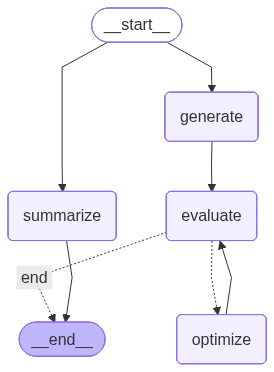

In [100]:
graph = StateGraph(PState)

graph.add_node('generate',generate)
graph.add_node('evaluate',evaluate)
graph.add_node('optimize',optimize)
graph.add_node('summarize',summarize)
# graph.add_node('condition',condition)

graph.add_edge(START,'generate')
graph.add_edge(START,'summarize')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate', condition, {
    'optimize': 'optimize',
    'end': END
})
graph.add_edge('optimize','evaluate')

graph.compile()


In [101]:
workflow = graph.compile()

final_state = workflow.invoke({'topic':'Agentic AI ', 'iteration':0 })


In [102]:
from pprint import pprint
pprint(final_state, width=200, depth=None, compact=False, sort_dicts=False)

{'topic': 'Agentic AI ',
 'post': '**Optimized LinkedIn Post:**\n'
         '\n'
         '**Unlocking Human Potential with Agentic AI: Where Technology Meets Empathy**\n'
         '\n'
         "As a seasoned Computer Science professional specializing in Generative AI/ML, I'm driven by the vision of a future where humans and intelligent machines collaborate to create a better "
         "world. With 3+ years of experience in building and deploying AI models using PyTorch, TensorFlow, and Keras, I've developed a unique expertise in natural language processing, computer "
         'vision, and reinforcement learning.\n'
         '\n'
         '**Key Insight:** I\'ve been exploring the concept of "value alignment" in Agentic AI, where AI systems learn to prioritize human values and goals. This requires a deep understanding of '
         "human psychology, ethics, and decision-making processes. For instance, I've successfully developed and deployed a personalized mental health support sys